# Phân tích Khám phá (EDA) - Lớp Bronze
Notebook này nhằm mục đích kiểm tra chất lượng và trực quan hóa 3 nguồn dữ liệu thô (Bronze Layer) vừa lấy về:
1. Dữ liệu Giá cổ phiếu (`vn_stocks`)
2. Dữ liệu Báo cáo tài chính (`vn_financials`)
3. Dữ liệu Kinh tế vĩ mô (`world_bank`)


In [1]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ xịn xò
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

from deltalake import DeltaTable
import os

# Hàm đọc dữ liệu từ Bronze Layer (sử dụng siêu kiến trúc Delta Lake)
def load_bronze(source):
    # Tự động trỏ đúng đường dẫn
    current_dir = os.getcwd()
    base_path = ".." if current_dir.endswith("notebooks") else "."
        
    path = os.path.join(base_path, "data", "bronze", source)
    
    if not os.path.exists(path):
        print(f"❌ Không tìm thấy thư mục Delta: {path}")
        return pd.DataFrame()
    
    try:
        # Nhờ sức mạnh của Delta Lake, ta đọc toàn bộ lịch sử trong nháy mắt
        dt = DeltaTable(path)
        df = dt.to_pandas()
        
        # Xóa các dòng trùng lặp (nếu chạy run_bronze nhiều lần, giữ lại lần gần nhất)
        df = df.drop_duplicates(subset=[c for c in df.columns if c != '_ingested_at'], keep='last')
        print(f"✅ Đã load {len(df)} dòng từ {source} (Phiên bản {dt.version()})")
        return df
    except Exception as e:
        print(f"⚠️ Lỗi đọc Delta Table {source}: {e}")
        return pd.DataFrame()


# Load cả 3 bảng
df_market = load_bronze("vn_stocks")
df_fin = load_bronze("vn_financials")
df_macro = load_bronze("world_bank")




✅ Đã load 10798 dòng từ vn_stocks (Phiên bản 15)
✅ Đã load 39 dòng từ vn_financials (Phiên bản 5)
✅ Đã load 24 dòng từ world_bank (Phiên bản 11)


## 1. Dữ liệu Thị trường (`vn_stocks`)
Phân tích diễn biến giá đóng cửa (Close Price) và Khối lượng giao dịch (Volume) của các ngân hàng.
Mục tiêu: Đảm bảo chuỗi thời gian không bị đứt gãy.


In [14]:
df_market.columns

print(df_market["trade_date"].min(), df_market["trade_date"].max())
print(df_market["trade_date"].dt.year.value_counts().sort_index())


2017-08-09 00:00:00 2026-05-27 00:00:00
trade_date
2017     408
2018    1149
2019    1250
2020    1260
2021    1250
2022    1245
2023    1245
2024    1250
2025    1245
2026     496
Name: count, dtype: int64


In [3]:
df_macro

,indicator_code,indicator_name,year,value,_ingested_at,_source
264,FP.CPI.TOTL.ZG,inflation_pct,2024,3.621093,2026-05-26T17:30:17.056283,world_bank
265,FP.CPI.TOTL.ZG,inflation_pct,2023,3.252893,2026-05-26T17:30:17.056283,world_bank
266,FP.CPI.TOTL.ZG,inflation_pct,2022,3.156507,2026-05-26T17:30:17.056283,world_bank
267,FP.CPI.TOTL.ZG,inflation_pct,2021,1.834716,2026-05-26T17:30:17.056283,world_bank
268,FP.CPI.TOTL.ZG,inflation_pct,2020,3.220934,2026-05-26T17:30:17.056283,world_bank
269,FP.CPI.TOTL.ZG,inflation_pct,2019,2.795824,2026-05-26T17:30:17.056283,world_bank
270,FP.CPI.TOTL.ZG,inflation_pct,2018,3.539628,2026-05-26T17:30:17.056283,world_bank
271,FP.CPI.TOTL.ZG,inflation_pct,2017,3.520257,2026-05-26T17:30:17.056283,world_bank
272,FR.INR.LEND,lending_rate_pct,2023,9.323000,2026-05-26T17:30:17.056283,world_bank
273,FR.INR.LEND,lending_rate_pct,2022,8.013333,2026-05-26T17:30:17.056283,world_bank


In [4]:
df_fin

,ticker,period,year,quarter,nim,npl_ratio,car,casa_ratio,roe,roa,_ingested_at,_source
33,TCB,2018-Q4,2018,4,0.042232,0.017528,0.143,0.286976,0.215313,0.028707,2026-05-27T03:36:34.202465,vn_financials
76,VCB,2018-Q1,2018,1,0.024984,0.013670,0.000,0.312832,0.191887,0.010968,2026-05-26T18:04:24.414888,vn_financials
77,VCB,2018-Q2,2018,2,0.025415,0.011522,0.000,0.299017,0.202632,0.011540,2026-05-26T18:04:24.414888,vn_financials
78,VCB,2018-Q3,2018,3,0.027000,0.011822,0.000,0.297209,0.209958,0.012050,2026-05-26T18:04:24.414888,vn_financials
79,VCB,2018-Q4,2018,4,0.027821,0.009849,0.000,0.303038,0.254592,0.013849,2026-05-26T18:04:24.414888,vn_financials
80,BID,2018-Q1,2018,1,0.029773,0.016170,0.000,0.177366,0.145155,0.006066,2026-05-26T18:04:24.414888,vn_financials
81,BID,2018-Q2,2018,2,0.029656,0.014894,0.000,0.179935,0.161933,0.006699,2026-05-26T18:04:24.414888,vn_financials
82,BID,2018-Q3,2018,3,0.028015,0.017592,0.000,0.172270,0.161103,0.006707,2026-05-26T18:04:24.414888,vn_financials
83,BID,2018-Q4,2018,4,0.028684,0.019017,0.000,0.171409,0.142339,0.005850,2026-05-26T18:04:24.414888,vn_financials
84,CTG,2018-Q1,2018,1,0.027419,0.012459,0.000,0.152700,0.124049,0.007271,2026-05-26T18:04:24.414888,vn_financials


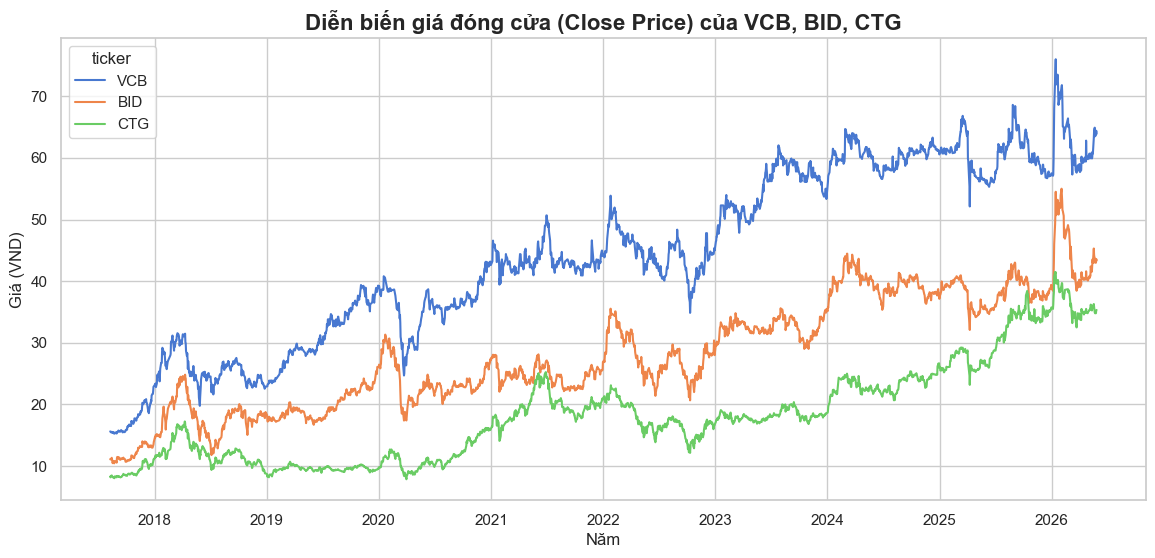

In [5]:
# Chuyển đổi trade_date sang datetime để vẽ trục X
df_market['trade_date'] = pd.to_datetime(df_market['trade_date'])

# Lọc 3 ngân hàng tiêu biểu
df_plot = df_market[df_market['ticker'].isin(['VCB', 'BID', 'CTG'])].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_plot, x='trade_date', y='close', hue='ticker')
plt.title("Diễn biến giá đóng cửa (Close Price) của VCB, BID, CTG", fontsize=16, fontweight='bold')
plt.ylabel("Giá (VND)")
plt.xlabel("Năm")
plt.show()


## 2. Dữ liệu BCTC (`vn_financials`)
Đây là trái tim của bài toán dự báo rủi ro ngân hàng. Chúng ta sẽ theo dõi 2 chỉ số sinh tử:
- **NPL (Nợ xấu):** Rủi ro tín dụng.
- **NIM (Biên lãi ròng):** Khả năng sinh lời từ lõi tín dụng.


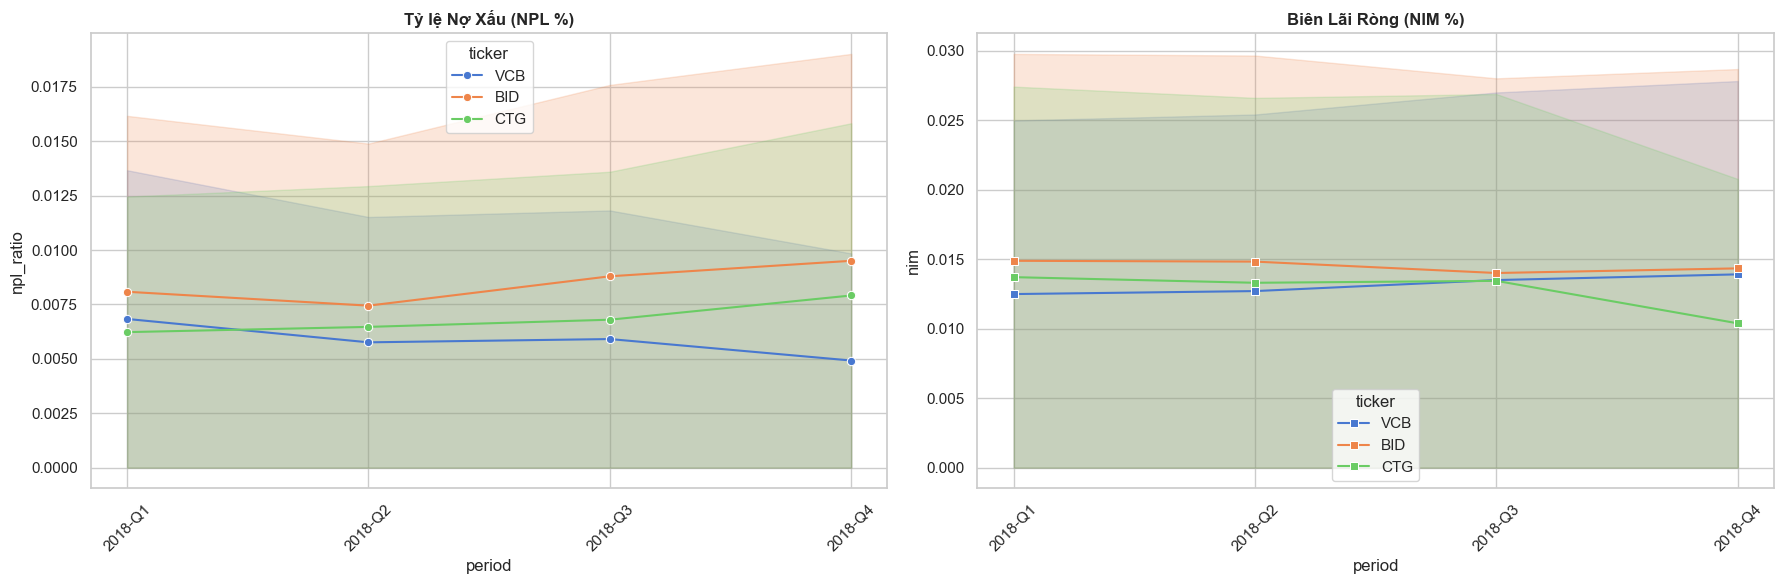

In [6]:
# Sắp xếp thời gian
df_fin_plot = df_fin[df_fin['ticker'].isin(['VCB', 'BID', 'CTG'])].copy()
df_fin_plot = df_fin_plot.sort_values(by=['year', 'quarter'])
df_fin_plot['period'] = df_fin_plot['year'].astype(str) + "-Q" + df_fin_plot['quarter'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ NPL
sns.lineplot(data=df_fin_plot, x='period', y='npl_ratio', hue='ticker', marker='o', ax=axes[0])
axes[0].set_title("Tỷ lệ Nợ Xấu (NPL %)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ NIM
sns.lineplot(data=df_fin_plot, x='period', y='nim', hue='ticker', marker='s', ax=axes[1])
axes[1].set_title("Biên Lãi Ròng (NIM %)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Dữ liệu Vĩ mô (`world_bank`)
Phân tích Tăng trưởng GDP và Lạm phát của Việt Nam. Đây là các yếu tố môi trường ảnh hưởng gián tiếp đến khả năng trả nợ của khách hàng vay vốn.


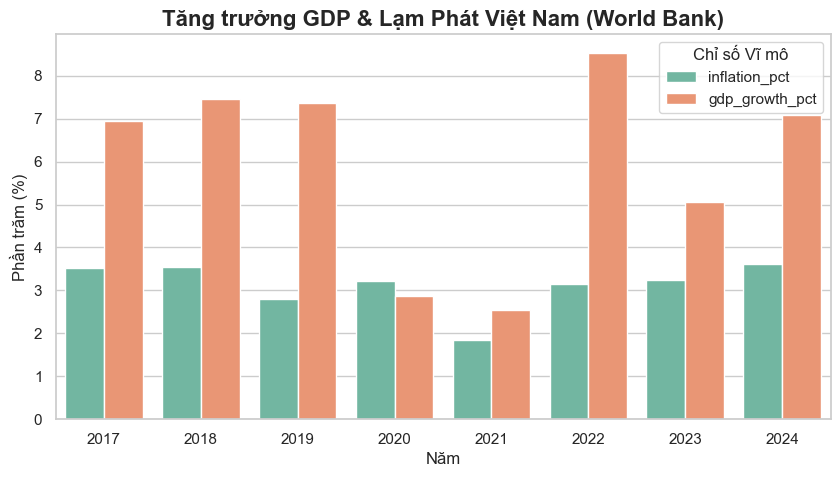

In [7]:
# Lọc Lạm phát (Inflation) và GDP Growth
df_macro_plot = df_macro[df_macro['indicator_name'].isin(['inflation_pct', 'gdp_growth_pct'])].sort_values('year')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_macro_plot, x='year', y='value', hue='indicator_name', palette='Set2')
plt.title("Tăng trưởng GDP & Lạm Phát Việt Nam (World Bank)", fontsize=16, fontweight='bold')
plt.ylabel("Phần trăm (%)")
plt.xlabel("Năm")
plt.legend(title="Chỉ số Vĩ mô")
plt.show()


In [3]:
import pandas as pd
from IPython.display import display, Markdown

paths = {
    "gold_full": "../data/gold/gold_full.parquet",
    "gold_fallback": "../data/gold/gold_fallback.parquet",
    "gold_latest_snapshot": "../data/gold/gold_latest_snapshot.parquet",
}

for name, p in paths.items():
    display(Markdown(f"## {name}"))
    display(Markdown(f"`{p}`"))

    df = pd.read_parquet(p)

    print("shape:", df.shape)
    print("n_columns:", len(df.columns))
    display(Markdown("### Columns"))
    display(pd.DataFrame({"column": df.columns}))

    display(Markdown("### Dtypes"))
    display(df.dtypes.rename("dtype").to_frame())

    display(Markdown("### Missing (%) - Top 20"))
    miss = (df.isna().mean() * 100).sort_values(ascending=False).head(20)
    display(miss.rename("missing_pct").to_frame())

    if "trade_date" in df.columns:
        d = pd.to_datetime(df["trade_date"], errors="coerce")
        display(Markdown("### Date Range"))
        print("trade_date min:", d.min())
        print("trade_date max:", d.max())

    if "ticker" in df.columns:
        display(Markdown("### Ticker Stats"))
        print("n_tickers:", df["ticker"].nunique())
        display(df["ticker"].value_counts().head(10).rename("rows").to_frame())

    display(Markdown("### Sample Rows"))
    display(df.head(5))
    print("-" * 100)

## gold_full

`../data/gold/gold_full.parquet`

shape: (1149, 27)
n_columns: 27


### Columns

,column
0,trade_date
1,ticker
2,bank_name
3,year
4,quarter
5,month
6,open
7,high
8,low
9,close


...

n_tickers: 5


,rows
ticker,
BID,1
CTG,1
MBB,1
TCB,1
VCB,1


### Sample Rows

,trade_date,ticker,bank_name,year,quarter,month,open,high,low,close,...,casa_ratio,roe,roa,gdp_growth_pct,inflation_pct,lending_rate_pct,ret_1d,ret_5d,volatility_20d,volume_chg_5d
0,2026-05-27,BID,BIDV,2026,2,5,43.85,43.85,43.3,43.35,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.005734,-0.012528,0.020128,-0.867257
1,2026-05-27,CTG,VietinBank,2026,2,5,35.30,35.45,35.2,35.30,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001418,0.002841,0.009989,-0.719497
2,2026-05-27,MBB,MB Bank,2026,2,5,25.55,25.60,25.3,25.40,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.003922,0.032520,0.009793,-0.905096
3,2026-05-27,TCB,Techcombank,2026,2,5,33.10,33.30,32.9,33.10,...,NaN,NaN,NaN,NaN,NaN,NaN,0.006079,0.020031,0.010375,-0.783749
4,2026-05-27,VCB,Vietcombank,2026,2,5,64.40,64.50,63.8,63.90,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.007764,-0.010836,0.013899,-0.889074


----------------------------------------------------------------------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'data/gold/gold_fallback.parquet'